In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../diabetes_milestone1_cleaned.csv')
df['CLASS'] = df['CLASS'].str.strip()
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,M,33,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
3,F,45,2.3,24.0,4.0,2.9,1.0,1.0,1.5,0.4,21.0,N
4,F,50,2.0,50.0,4.0,3.6,1.3,0.9,2.1,0.6,24.0,N


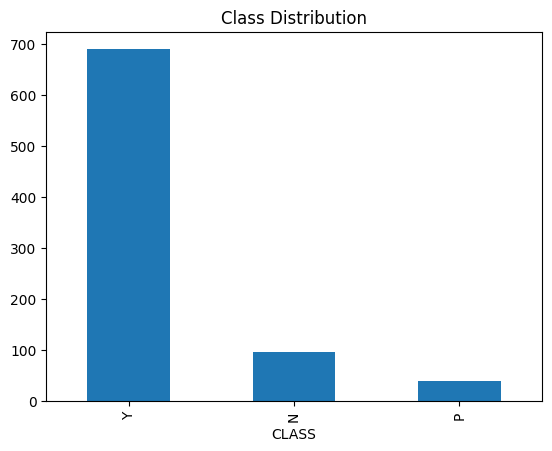

In [2]:
# Class distribution (Y=Diabetic, N=Normal, P=Pre-diabetic)
df['CLASS'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.show()

690 diabetic (Y), 96 normal (N), 40 pre-diabetic (P) — the dataset is heavily skewed toward diabetic cases.

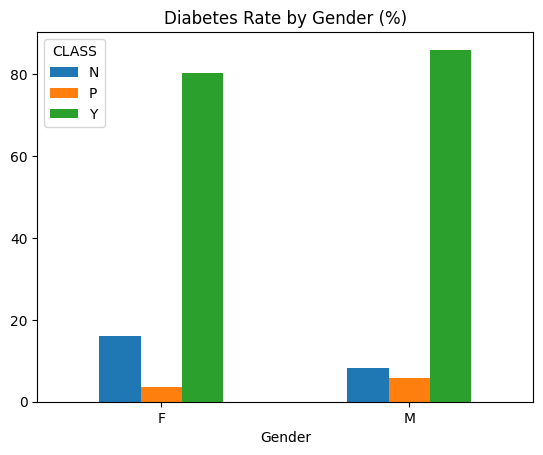

In [3]:
# Are women or men more prone?
pd.crosstab(df['Gender'], df['CLASS'], normalize='index').mul(100).round(1).plot(kind='bar')
plt.title('Diabetes Rate by Gender (%)')
plt.xticks(rotation=0)
plt.show()

men are slightly more prone — 86% of males are diabetic vs 80.4% of females.

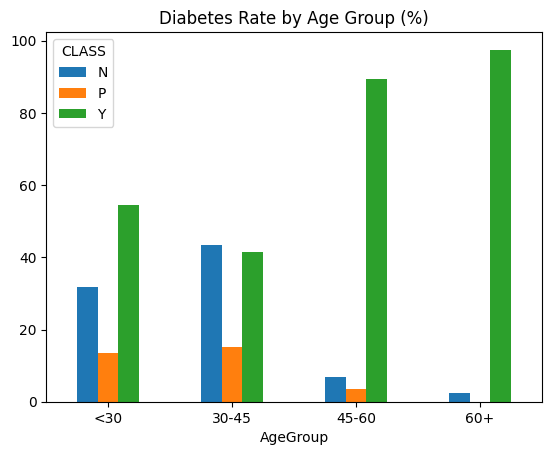

Young people under 30 who are diabetic: 71.4%


In [4]:
# Are younger people prone?
df['AgeGroup'] = pd.cut(df['AGE'], bins=[0,30,45,60,100], labels=['<30','30-45','45-60','60+'])
pd.crosstab(df['AgeGroup'], df['CLASS'], normalize='index').mul(100).round(1).plot(kind='bar')
plt.title('Diabetes Rate by Age Group (%)')
plt.xticks(rotation=0)
plt.show()

young = df[df['AGE'] < 30]
pct = (young['CLASS'] == 'Y').sum() / len(young) * 100
print(f'Young people under 30 who are diabetic: {pct:.1f}%')

diabetes increases with age — 60+ group has the highest rate at 97.5%. but even under-30s are 71.4% diabetic, which is surprisingly high.

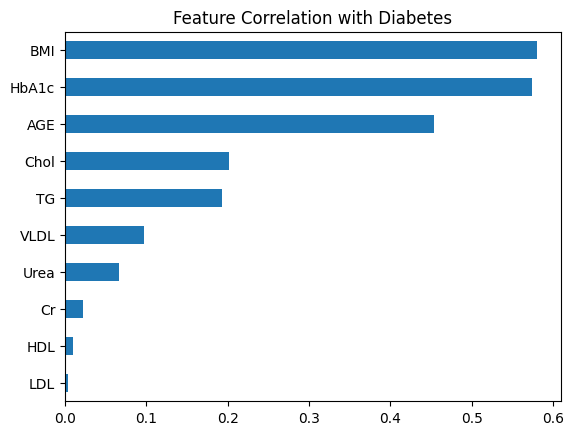

In [5]:
# Which features are most linked to diabetes?
df['CLASS_num'] = df['CLASS'].map({'N': 0, 'P': 1, 'Y': 2})
features = ['AGE','Urea','Cr','HbA1c','Chol','TG','HDL','LDL','VLDL','BMI']
df[features].corrwith(df['CLASS_num']).sort_values().plot(kind='barh')
plt.title('Feature Correlation with Diabetes')
plt.show()

BMI and HbA1c are the top two factors (correlation ~0.58 each), followed by AGE (0.45). LDL, HDL, and Cr have almost no correlation.

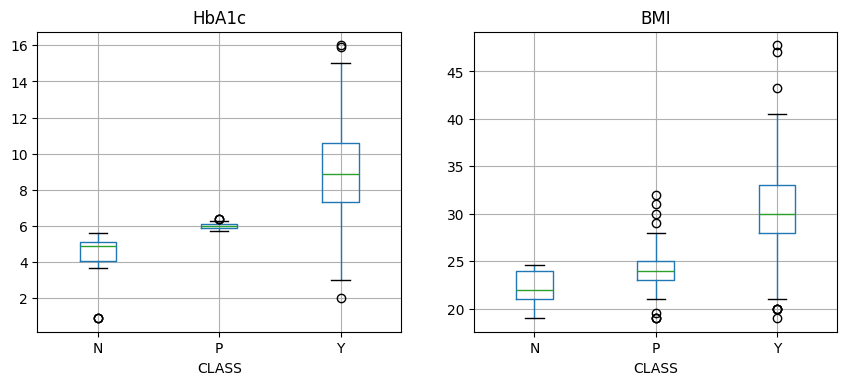

In [6]:
# HbA1c and BMI by class (top 2 factors)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df.boxplot(column='HbA1c', by='CLASS', ax=axes[0])
df.boxplot(column='BMI', by='CLASS', ax=axes[1])
plt.suptitle('')
plt.show()

diabetic patients have clearly higher HbA1c (avg 8.98 vs 4.58) and higher BMI (avg 30.76 vs 22.35) compared to normal patients.

In [7]:
# Average values per class
df.groupby('CLASS')[features].mean().round(2)

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
CLASS,,,,,,,,,,
N,44.27,4.74,63.24,4.58,4.25,1.66,1.21,2.62,0.97,22.35
P,43.40,4.54,69.15,6.01,4.42,2.15,1.13,2.37,1.01,24.11
Y,55.36,5.28,66.60,8.98,5.02,2.52,1.22,2.60,1.93,30.76


diabetic patients are on average older (55 vs 44), have higher HbA1c (8.98 vs 4.58), higher BMI (30.76 vs 22.35), and higher TG (2.52 vs 1.66). these are the main distinguishing features.